# Import data from UCI Machine Learning Repository
### Dataset: Online Retail
https://archive.ics.uci.edu/dataset/352/online+retail

In [42]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [43]:
from ucimlrepo import fetch_ucirepo 
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
df = online_retail.data.original 

In [44]:
df.shape
df.to_csv('Online Retail.csv', index=False)

# Data Cleaning
Using SQL to clean data to demonstrate capability

In [45]:
# Filtering dataset
df = duckdb.sql(
    """
    WITH main_unfiltered AS(
        SELECT
            Country                                                                                 AS country,
            Description                                                                             AS description,
            Quantity                                                                                AS quantity,
            CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)                                   AS invoice_date,
            UnitPrice                                                                               AS unit_price,
            CAST(CustomerID AS STRING)                                                              AS customer_id,
            Country                                                                                 AS country,
            InvoiceNo                                                                               AS invoice_number,
            MAX(CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)) OVER ()                      AS global_max_date
        FROM
            df
    ),

    main AS (
        SELECT
            *
        FROM
            main_unfiltered
        WHERE
            invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter out the last 90 days, this will be used for target variables
            AND description = UPPER(description) -- Filtering to just Products, Products are capitalised and adjustments such as discounts are lowercase
    ),

    max_invoice_date AS (
        SELECT
            MAX(invoice_date) AS max_date
        FROM 
            main
    ),

    customer_lifespan AS (
        SELECT
            customer_id,
            DATEDIFF('day', MIN(invoice_date), MAX(invoice_date)) AS customer_lifespan_days,
            COUNT(DISTINCT invoice_number) AS life_time_orders,
            SUM(quantity*unit_price) AS total_spend, 
            MAX(invoice_date) AS last_order_date 
        FROM
            main
        WHERE
            customer_id IS NOT NULL
        GROUP BY
            customer_id
    ),

    discount AS (
        SELECT
            customer_id,
            invoice_date,
            SUM(quantity*unit_price) AS discount,
            COUNT(invoice_number) AS number_of_discounts 
        FROM
            main_unfiltered
        WHERE
            description = 'Discount'
            AND invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH')
        GROUP BY
            customer_id, 
            invoice_date
    ),

    returns AS (
        SELECT
            customer_id,
            SUM(quantity) *-1                   AS units_returned,
            SUM(quantity*unit_price) *-1        AS total_returns_value,
            COUNT(Distinct invoice_date)        AS number_of_orders_returned
        FROM
            main
        WHERE
            quantity < 0 -- Negative quantities are returned orders
        GROUP BY
            customer_id

    ),

    recent AS (
        SELECT
            a.customer_id,
            SUM(a.quantity * a.unit_price)  AS "recent_spend",
            COUNT(DISTINCT  a.invoice_number) AS "recent_orders"
        FROM
            main a
        CROSS JOIN
            max_invoice_date b 
        WHERE
            a.invoice_date >= DATE_ADD(b.max_date, INTERVAL '-60 DAY') -- Filter to last 60 days of data
        GROUP BY
            customer_id
    ),

    target_variable AS (
        SELECT DISTINCT
            customer_id,
            0 as customer_churned
        FROM 
            main_unfiltered
        WHERE
            invoice_date >= DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter to the last 90 days of data
    ),
    
    final AS (
        SELECT 
            a.customer_id,
            COUNT(DISTINCT a.description)                                               AS unique_products_purchased,
            SUM(a.quantity * a.unit_price)                                              AS total_spend,
            MAX(b.customer_lifespan_days)                                               AS customer_age_days,
            MAX(b.life_time_orders)                                                     AS total_orders,
            SUM(a.quantity * a.unit_price) / MAX(b.life_time_orders)                    AS average_order_value,
            MAX(b.customer_lifespan_days) / (MAX(b.life_time_orders) -1)                AS order_frequency,
            SUM(IFNULL(c.discount * -1, 0))                                             AS total_discount_value,
            MAX(IFNULL(c.number_of_discounts, 0))                                       AS orders_with_discounts,
            DATEDIFF('day', MAX(a.invoice_date), MAX(e.max_date))                       AS days_since_last_order,
            MAX(IFNULL(f.units_returned ,0))                                            AS units_returned,
            MAX(IFNULL(f.total_returns_value ,0))                                       AS total_returns_value,
            MAX(IFNULL(f.number_of_orders_returned ,0))                                 AS number_of_orders_returned,
            IFNULL(MAX(f.number_of_orders_returned) ,0) / MAX(b.life_time_orders)       AS orders_returned_ratio,
            CASE WHEN MAX(b.life_time_orders) <= 1 THEN 1 ELSE 0 END                    AS one_time_buyer,
            MAX(g.recent_spend) / (SUM(a.quantity * a.unit_price))                       AS recent_vs_historical_spend,
            MAX(g.recent_orders) / MAX(b.life_time_orders)                              AS recent_order_ratio,
            MAX(IFNULL(d.customer_churned, 1))                                          AS customer_churned
        FROM 
            main a
        LEFT JOIN
            customer_lifespan b USING (customer_id)
        LEFT JOIN
            discount c USING (customer_id) -- Can sum create the count of discounts per customer then get the sum for total discount and avg discount
        LEFT JOIN
            target_variable d USING (customer_id)
        CROSS JOIN 
            max_invoice_date e
        LEFT JOIN
            returns f USING (customer_id)
        LEFT JOIN
            recent g USING(customer_id)
        GROUP BY
            customer_id
    )

    SELECT * FROM final
    """
).df()

df

,customer_id,unique_products_purchased,total_spend,customer_age_days,total_orders,average_order_value,order_frequency,total_discount_value,orders_with_discounts,days_since_last_order,units_returned,total_returns_value,number_of_orders_returned,orders_returned_ratio,one_time_buyer,recent_vs_historical_spend,recent_order_ratio,customer_churned
0,12408.0,67,2103.07,162,7,300.438571,27.0,0.0,0,6,9.0,30.98,3,0.428571,0,0.305401,0.142857,0
1,14395.0,114,1956.27,195,7,279.467143,32.5,0.0,0,85,1.0,9.95,1,0.142857,0,NaN,NaN,0
2,12347.0,82,2790.86,238,5,558.172000,59.5,0.0,0,37,0.0,0.00,0,0.000000,0,0.209581,0.200000,0
3,16515.0,63,987.61,161,3,329.203333,80.5,0.0,0,58,0.0,0.00,0,0.000000,0,0.369863,0.333333,0
4,14449.0,99,401.30,126,2,200.650000,126.0,0.0,0,154,0.0,0.00,0,0.000000,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389,14762.0,21,300.52,0,1,300.520000,NaN,0.0,0,171,0.0,0.00,0,0.000000,1,NaN,NaN,1
3390,12355.0,13,459.40,0,1,459.400000,NaN,0.0,0,122,0.0,0.00,0,0.000000,1,NaN,NaN,1
3391,18191.0,7,207.80,0,1,207.800000,NaN,0.0,0,169,0.0,0.00,0,0.000000,1,NaN,NaN,1
3392,12672.0,10,225.90,0,1,225.900000,NaN,0.0,0,237,0.0,0.00,0,0.000000,1,NaN,NaN,1


# Logistic Regression
Visualising the input variables

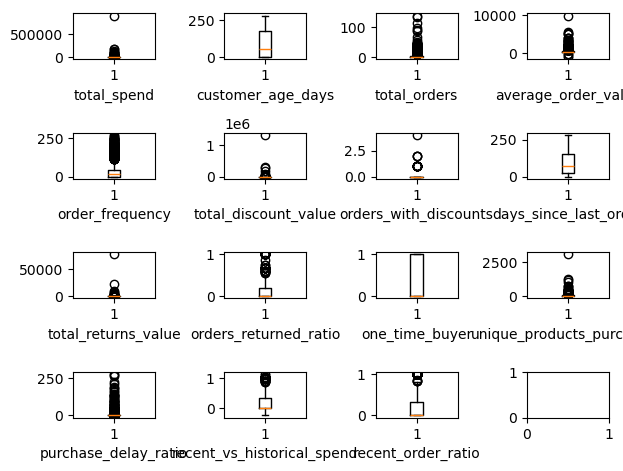

In [46]:
# Investigating & Cleaning Outliers
df['purchase_delay_ratio'] = df['days_since_last_order'] / df['order_frequency']

features = ['total_spend', 'customer_age_days', 'total_orders',
            'average_order_value', 'order_frequency', 'total_discount_value',
            'orders_with_discounts', 'days_since_last_order', 'total_returns_value',
            'orders_returned_ratio', 'one_time_buyer', 'unique_products_purchased',
            'purchase_delay_ratio', 'recent_vs_historical_spend','recent_order_ratio']

# Set infinite or null values to 0
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df[features] = df[features].fillna(0)


def boxplots(df, features):
    figure, axes = plt.subplots(4, 4)
    axes = axes.flatten()

    i = 0
    for col in features:
        axes[i].boxplot(df[col])
        axes[i].set_xlabel(col)
        i += 1

    plt.tight_layout()
    plt.show()

boxplots(df, features)

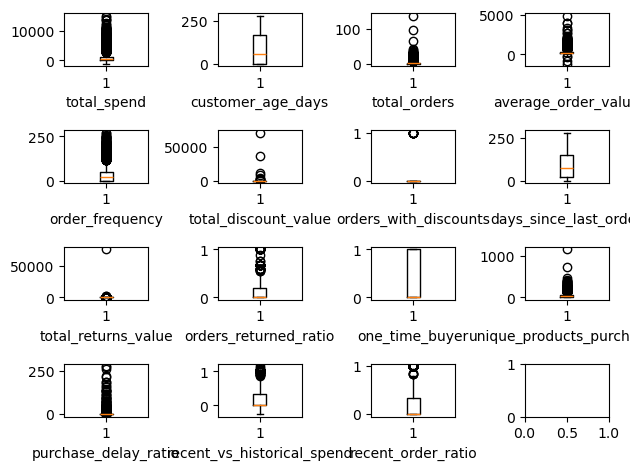

In [47]:
# Remove extreme outliers
df_clean = df[df['total_spend'] < df['total_spend'].quantile(0.99)]
boxplots(df_clean, features)

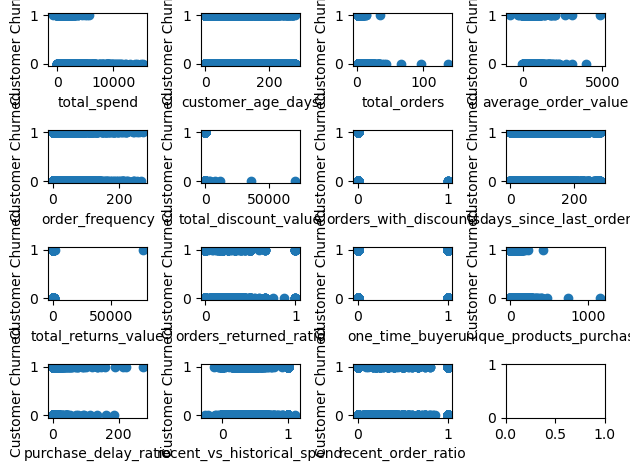

In [48]:
# Split data into train and test
from sklearn.model_selection import train_test_split

# Convert dataframe into Numpy array
X = df_clean[features].to_numpy()
y = df_clean['customer_churned'].to_numpy()

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)

m,n = X_train.shape

figure, axes = plt.subplots(4, 4)
axes = axes.flatten()

for i in range(n):
    axes[i].scatter(X_train[:,i], y_train)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('Customer Churned')

plt.tight_layout()
plt.show()

### Investigate Multicollinearity using Variance Inflation Factor

In [49]:
# Investigating colinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = df[features].copy()
x = x.astype(float)
x = add_constant(x)

df_vif = pd.DataFrame({
    'Feature' : x.columns,
    'VIF' : [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
})

df_vif = df_vif[df_vif['Feature'] != 'const'].reset_index(drop=True)

print(df_vif)

                       Feature        VIF
0                  total_spend   2.253696
1            customer_age_days   4.098705
2                 total_orders   2.587800
3          average_order_value   1.104165
4              order_frequency   2.167519
5         total_discount_value   1.378896
6        orders_with_discounts   1.360194
7        days_since_last_order   3.298908
8          total_returns_value   1.024745
9        orders_returned_ratio   1.309720
10              one_time_buyer   2.915446
11   unique_products_purchased   3.109641
12        purchase_delay_ratio   1.233030
13  recent_vs_historical_spend  12.968474
14          recent_order_ratio  13.620936


# Logistic Regression
Running the model

Accuracy: 0.6901041666666666
Actual: [0 1 1 ... 0 0 1]
Predicted: [1 1 1 ... 0 1 0]

total_spend: -0.705363698908208
customer_age_days: -0.354931136222495
total_orders: -0.26969549139454296
average_order_value: 0.14227641830630872
order_frequency: 0.1903289940689756
total_discount_value: -0.05760026671776718
orders_with_discounts: -0.2481256435270449
days_since_last_order: 0.15586311711304618
total_returns_value: 0.09154380701673517
orders_returned_ratio: -0.021413510011005096
one_time_buyer: 0.11946092114059323
unique_products_purchased: -0.337347449285779
purchase_delay_ratio: 0.12143201180246464
recent_vs_historical_spend: -0.4612557867335712
recent_order_ratio: 0.3605085449938091


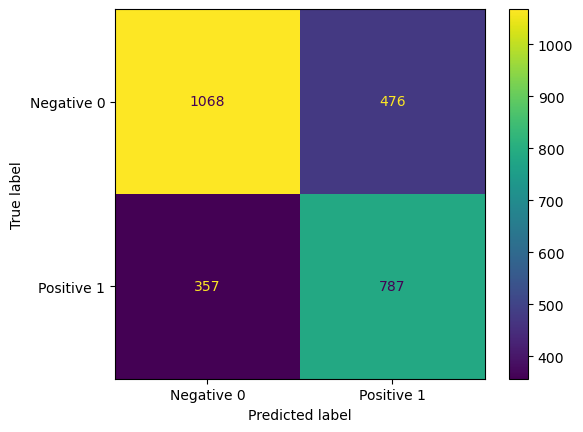

In [61]:
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

scaler = StandardScaler()

# Scaling input features
X_train_scaled = scaler.fit_transform(X_train)

logr = linear_model.LogisticRegression()

logr.fit(X_train_scaled, y_train)
y_pred = logr.predict(X_train_scaled)

def evaluate(y_train, y_pred):
    print(f'Accuracy: {accuracy_score(y_train, y_pred)}')
    print(f'Actual: {y_train}\nPredicted: {y_pred}\n')

    j = 0
    for col in features:
        print(f'{col}: {logr.coef_[0][j]}')
        j += 1

    matrix = confusion_matrix(y_train, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, 
                                        display_labels= ['Negative 0', 'Positive 1'])
    cm_display.plot()

evaluate(y_train, y_pred)

### Including Polynomial Features

Accuracy: 0.7101934523809523
Actual: [0 1 1 ... 0 0 1]
Predicted: [1 1 1 ... 0 1 0]

total_spend: -0.705363698908208
customer_age_days: -0.354931136222495
total_orders: -0.26969549139454296
average_order_value: 0.14227641830630872
order_frequency: 0.1903289940689756
total_discount_value: -0.05760026671776718
orders_with_discounts: -0.2481256435270449
days_since_last_order: 0.15586311711304618
total_returns_value: 0.09154380701673517
orders_returned_ratio: -0.021413510011005096
one_time_buyer: 0.11946092114059323
unique_products_purchased: -0.337347449285779
purchase_delay_ratio: 0.12143201180246464
recent_vs_historical_spend: -0.4612557867335712
recent_order_ratio: 0.3605085449938091


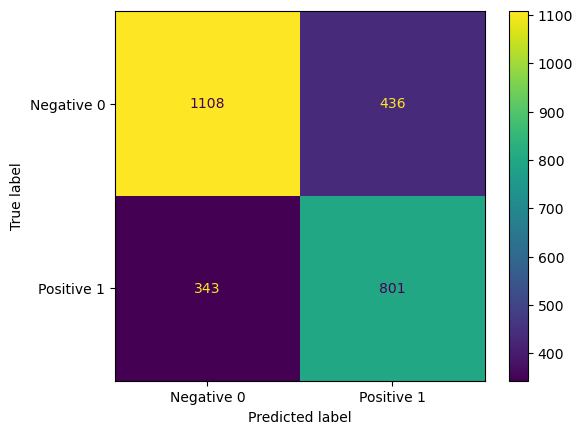

In [62]:
poly = PolynomialFeatures(degree=3)

def transform(X):
    X_poly = poly.fit_transform(X)
    X_poly_scaled = scaler.fit_transform(X_poly)

    return X_poly_scaled

X_train_poly = transform(X_train)

logr_poly = linear_model.LogisticRegression(max_iter=2000, C=0.1, random_state=42)
logr_poly.fit(X_train_poly, y_train)
y_pred_poly = logr_poly.predict(X_train_poly)
y_pred_poly_proba = logr_poly.predict_proba(X_train_poly)[:, 1]

evaluate(y_train, y_pred_poly)

Accuracy: 0.6532738095238095
Actual: [0 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1
 0 1 0 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 0 0 1 0 0
 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0
 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 0 1
 1 0 1 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 1 1 1 0 0 0 1 0
 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 1 1 0 1 0 1 0 1 1 0 1 1 1 1 0 0 0 1 0 1 1
 0 1 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 0 0 0 1 1
 1 0 1 0 1 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1
 1 0 1 0 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 0
 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 0 1 1 0 0 0 1
 0 1 0 0 1 0 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0
 0 1 0 0 1 1 1 0 1 1 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 0 

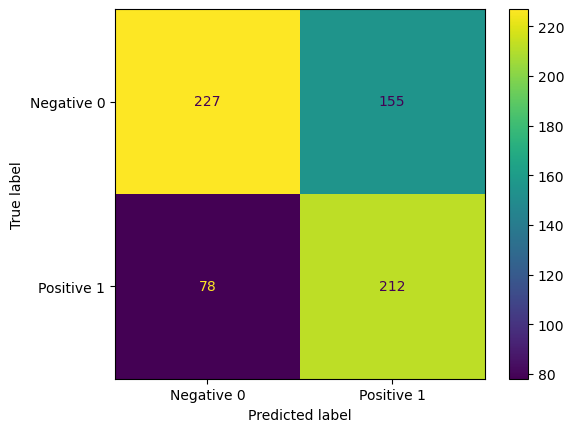

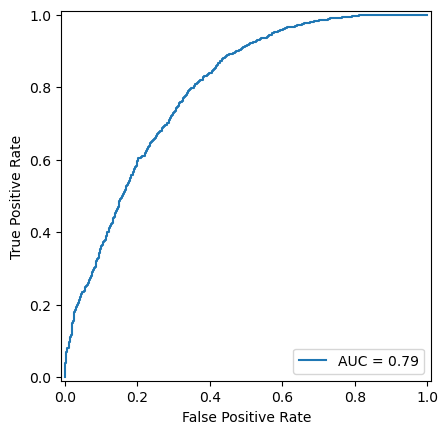

In [63]:
X_test_poly = poly.fit_transform(X_test)
X_test_poly = scaler.fit_transform(X_test_poly)
y_pred_poly = logr_poly.predict(X_test_poly)

evaluate(y_test, y_pred_poly)

fpr, tpr, thresholds = roc_curve(y_train, y_pred_poly_proba)
roc_auc = auc(fpr, tpr)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()

# Outputting model results

In [64]:
X = df[features].to_numpy()
X_transform = transform(X)
y_pred = logr_poly.predict_proba(X_transform)[:, 1]

df['churn_probability'] = y_pred.ravel()

df.to_csv('Customer Churn Predictions.csv', index=False)
df

,customer_id,unique_products_purchased,total_spend,customer_age_days,total_orders,average_order_value,order_frequency,total_discount_value,orders_with_discounts,days_since_last_order,units_returned,total_returns_value,number_of_orders_returned,orders_returned_ratio,one_time_buyer,recent_vs_historical_spend,recent_order_ratio,customer_churned,purchase_delay_ratio,churn_probability
0,12408.0,67,2103.07,162,7,300.438571,27.0,0.0,0,6,9.0,30.98,3,0.428571,0,0.305401,0.142857,0,0.222222,0.167229
1,14395.0,114,1956.27,195,7,279.467143,32.5,0.0,0,85,1.0,9.95,1,0.142857,0,0.000000,0.000000,0,2.615385,0.206637
2,12347.0,82,2790.86,238,5,558.172000,59.5,0.0,0,37,0.0,0.00,0,0.000000,0,0.209581,0.200000,0,0.621849,0.198887
3,16515.0,63,987.61,161,3,329.203333,80.5,0.0,0,58,0.0,0.00,0,0.000000,0,0.369863,0.333333,0,0.720497,0.195525
4,14449.0,99,401.30,126,2,200.650000,126.0,0.0,0,154,0.0,0.00,0,0.000000,0,0.000000,0.000000,0,1.222222,0.347287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389,14762.0,21,300.52,0,1,300.520000,0.0,0.0,0,171,0.0,0.00,0,0.000000,1,0.000000,0.000000,1,0.000000,0.539526
3390,12355.0,13,459.40,0,1,459.400000,0.0,0.0,0,122,0.0,0.00,0,0.000000,1,0.000000,0.000000,1,0.000000,0.571028
3391,18191.0,7,207.80,0,1,207.800000,0.0,0.0,0,169,0.0,0.00,0,0.000000,1,0.000000,0.000000,1,0.000000,0.581901
3392,12672.0,10,225.90,0,1,225.900000,0.0,0.0,0,237,0.0,0.00,0,0.000000,1,0.000000,0.000000,1,0.000000,0.584186
